Project M3 Submission B1, Team 1

# Load Data & Packages

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import hdbscan

In [53]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2023/2023-06-13/safi_data.csv"
safi = pd.read_csv(url)

In [54]:
print("Shape:", safi.shape)
safi.head()

Shape: (131, 14)


,key_ID,village,interview_date,no_membrs,years_liv,respondent_wall_type,rooms,memb_assoc,affect_conflicts,liv_count,items_owned,no_meals,months_lack_food,instanceID
0,1,God,2016-11-17T00:00:00Z,3,4,muddaub,1,NaN,NaN,1,bicycle;television;solar_panel;table,2,Jan,uuid:ec241f2c-0609-46ed-b5e8-fe575f6cefef
1,1,God,2016-11-17T00:00:00Z,7,9,muddaub,1,yes,once,3,cow_cart;bicycle;radio;cow_plough;solar_panel;...,2,Jan;Sept;Oct;Nov;Dec,uuid:099de9c9-3e5e-427b-8452-26250e840d6e
2,3,God,2016-11-17T00:00:00Z,10,15,burntbricks,1,NaN,NaN,1,solar_torch,2,Jan;Feb;Mar;Oct;Nov;Dec,uuid:193d7daf-9582-409b-bf09-027dd36f9007
3,4,God,2016-11-17T00:00:00Z,7,6,burntbricks,1,NaN,NaN,2,bicycle;radio;cow_plough;solar_panel;mobile_phone,2,Sept;Oct;Nov;Dec,uuid:148d1105-778a-4755-aa71-281eadd4a973
4,5,God,2016-11-17T00:00:00Z,7,40,burntbricks,1,NaN,NaN,4,motorcyle;radio;cow_plough;mobile_phone,2,Aug;Sept;Oct;Nov,uuid:2c867811-9696-4966-9866-f35c3e97d02d


Feature Engineering

In [55]:
# Clean categorical
for c in ["memb_assoc","affect_conflicts"]:
    safi[c] = safi[c].fillna("unknown").str.lower().str.strip()

# Food insecurity count
safi["months_lack_food_count"] = (
    safi["months_lack_food"]
    .fillna("")
    .str.split(";")
    .apply(lambda x: len([m for m in x if m.strip() not in ["none",""]]))
)

# Asset count
safi["items_owned_count"] = (
    safi["items_owned"]
    .fillna("")
    .str.split(";")
    .apply(lambda x: len([i for i in x if i.strip() != ""]))
)


Numeric Feature Set (Used Across Methods)

In [56]:
features = [
    "no_membrs",
    "liv_count",
    "rooms",
    "no_meals",
    "months_lack_food_count",
    "years_liv",
    "items_owned_count"
]

X = safi[features].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

EDA

In [57]:
#Distributions (for every clustering feature)
cluster_features = [
    "no_membrs",
    "liv_count",
    "rooms", "no_meals",
    "months_lack_food_count",
    "years_liv",
    "items_owned_count"
]

cluster_features = [c for c in cluster_features if c in safi.columns]

safi[cluster_features].describe()

,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
count,131.00000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,7.19084,2.366412,1.740458,2.603053,2.320611,23.053435,4.740458
std,3.17227,1.082775,1.092547,0.491143,1.997179,16.913041,3.153966
min,2.00000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000
25%,5.00000,1.000000,1.000000,2.000000,0.000000,12.000000,2.000000
50%,7.00000,2.000000,1.000000,3.000000,2.000000,20.000000,5.000000
75%,9.00000,3.000000,2.000000,3.000000,3.000000,27.500000,7.000000
max,19.00000,5.000000,8.000000,3.000000,11.000000,96.000000,15.000000


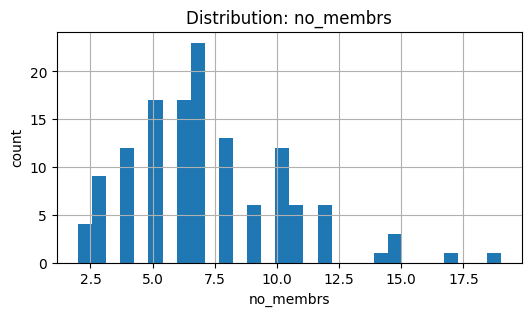

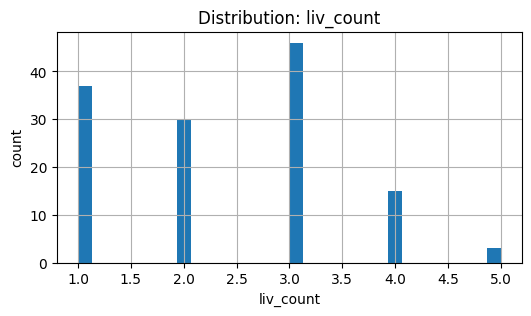

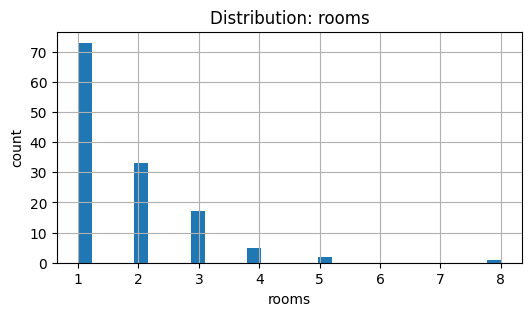

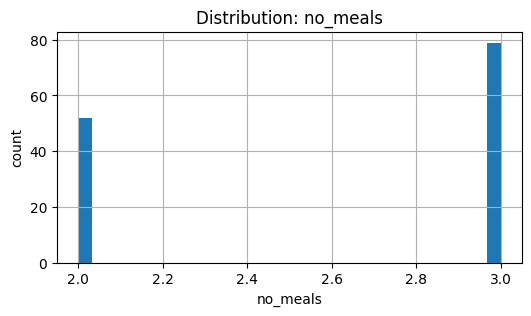

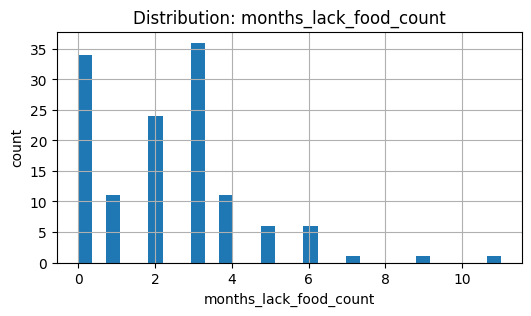

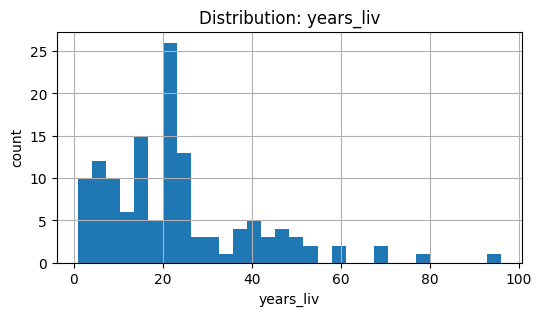

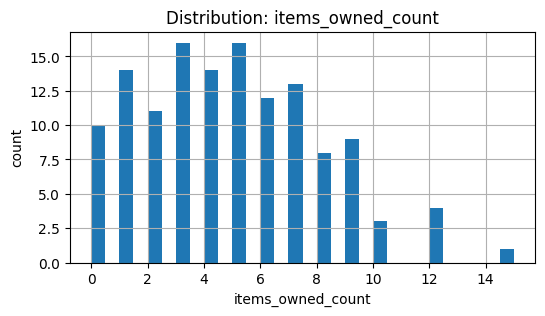

In [58]:
for c in cluster_features:
    plt.figure(figsize=(6,3))
    safi[c].hist(bins=30)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

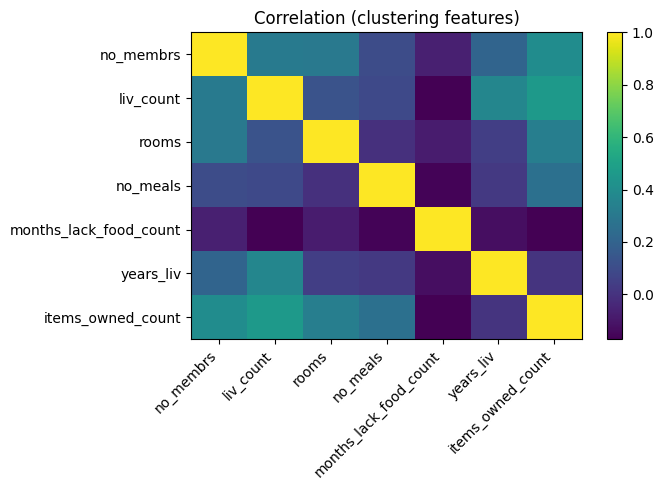

In [59]:
#Correlation heatmap
corr = safi[cluster_features].corr(numeric_only=True)

plt.figure(figsize=(7,5))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation (clustering features)")
plt.tight_layout()
plt.show()

In [60]:
# Group comparisons (membership/village vs features)
if "memb_assoc" in safi.columns:
    display(safi.groupby("memb_assoc")[cluster_features].mean(numeric_only=True))

if "village" in safi.columns:
    display(safi.groupby("village")[cluster_features].mean(numeric_only=True).head(10))

,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
memb_assoc,,,,,,,
no,7.406780,2.525424,1.745763,2.610169,2.000000,22.406780,5.152542
unknown,5.769231,1.897436,1.692308,2.538462,2.820513,20.128205,3.487179
yes,8.484848,2.636364,1.787879,2.666667,2.303030,27.666667,5.484848


,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
village,,,,,,,
Chirodzo,7.076923,2.256410,1.974359,2.615385,2.102564,23.615385,4.538462
God,6.860465,2.232558,1.534884,2.558140,3.000000,20.418605,3.976744
Ruaca,7.571429,2.571429,1.734694,2.632653,1.897959,24.918367,5.571429


KMeans — Elbow + Silhouette

Elbow

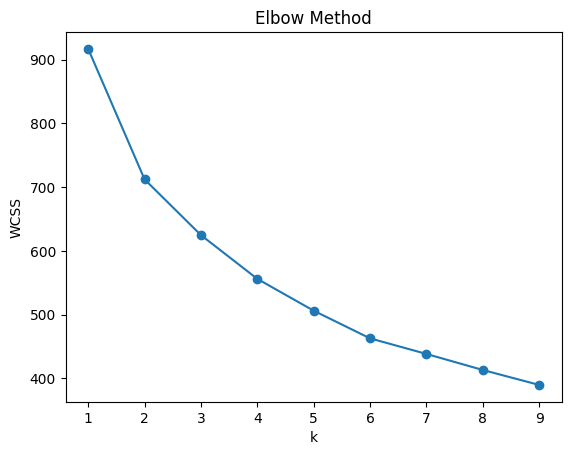

In [61]:
wcss = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

Silhouette

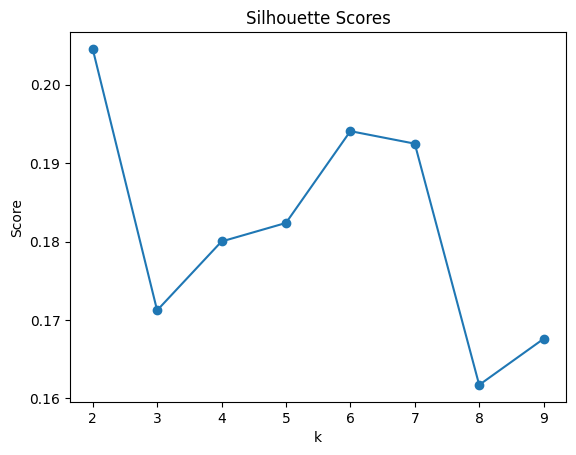

In [62]:
sil_scores = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,10), sil_scores, marker="o")
plt.title("Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

Fit Final KMeans

In [63]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
safi["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

Improved Outlier Detection

In [64]:
centroids = kmeans.cluster_centers_
labels = safi["kmeans_cluster"].values

distances = np.linalg.norm(X_scaled - centroids[labels], axis=1)
safi["distance_to_centroid"] = distances

safi["distance_z"] = (
    safi.groupby("kmeans_cluster")["distance_to_centroid"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

safi["economic_outlier"] = safi["distance_z"] > 2

PCA Visualization

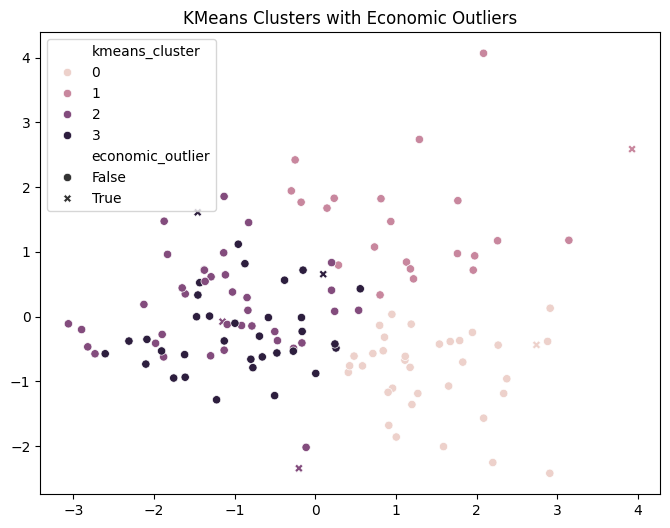

In [65]:
coords = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=coords[:,0],
    y=coords[:,1],
    hue=safi["kmeans_cluster"],
    style=safi["economic_outlier"]
)
plt.title("KMeans Clusters with Economic Outliers")
plt.show()

UMAP n_neighbors sensitivty

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


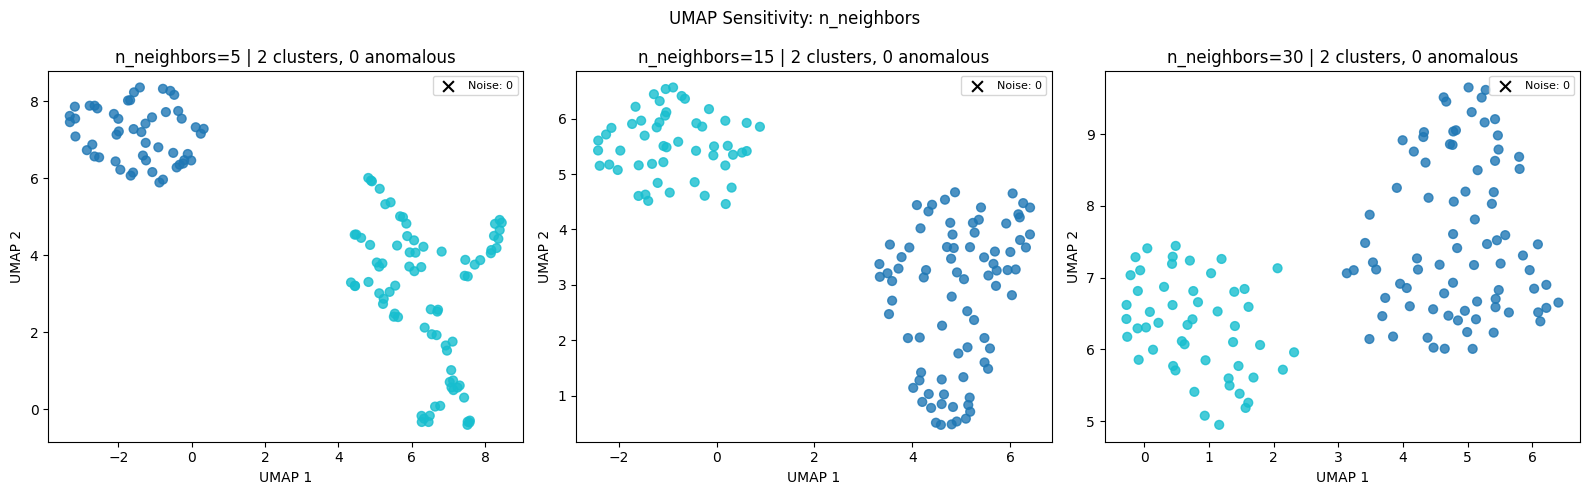

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
embeddings = {}

for ax, n in zip(axes, [5, 15, 30]):
    emb = umap.UMAP(n_neighbors=n, min_dist=0.1, random_state=42).fit_transform(X_scaled)
    embeddings[n] = emb
    lbl = hdbscan.HDBSCAN(min_cluster_size=10).fit_predict(emb)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()

    ax.scatter(emb[lbl != -1, 0], emb[lbl != -1, 1], c=lbl[lbl != -1], cmap='tab10', s=40, alpha=0.8)
    ax.scatter(emb[lbl == -1, 0], emb[lbl == -1, 1], c='black', s=60, marker='x', label=f'Noise: {n_noise}')
    ax.set_title(f"n_neighbors={n} | {n_c} clusters, {n_noise} anomalous")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.legend(fontsize=8)

plt.suptitle("UMAP Sensitivity: n_neighbors", fontsize=12)
plt.tight_layout()
plt.show()

UMAP min_dist sensitivity

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


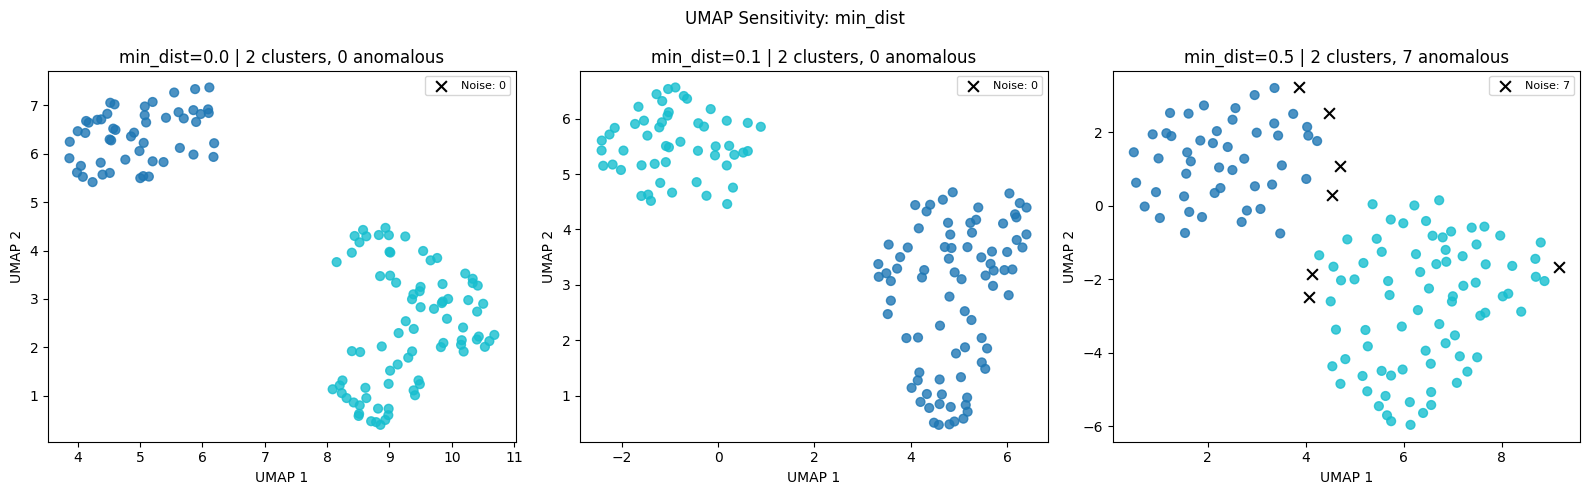

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, md in zip(axes, [0.0, 0.1, 0.5]):
    emb = umap.UMAP(n_neighbors=15, min_dist=md, random_state=42).fit_transform(X_scaled)
    lbl = hdbscan.HDBSCAN(min_cluster_size=10).fit_predict(emb)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()

    ax.scatter(emb[lbl != -1, 0], emb[lbl != -1, 1], c=lbl[lbl != -1], cmap='tab10', s=40, alpha=0.8)
    ax.scatter(emb[lbl == -1, 0], emb[lbl == -1, 1], c='black', s=60, marker='x', label=f'Noise: {n_noise}')
    ax.set_title(f"min_dist={md} | {n_c} clusters, {n_noise} anomalous")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.legend(fontsize=8)

plt.suptitle("UMAP Sensitivity: min_dist", fontsize=12)
plt.tight_layout()
plt.show()

HBDSCAN min_cluster_scan Tuning

In [68]:
embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)

results = []
for mcs in [5, 8, 10, 15, 20]:
    lbl = hdbscan.HDBSCAN(min_cluster_size=mcs).fit_predict(embedding)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()
    sil = silhouette_score(embedding, lbl) if n_c > 1 else None
    results.append({"min_cluster_size": mcs, "n_clusters": n_c,
                    "n_noise": n_noise, "silhouette": round(sil, 3) if sil else None})

display(pd.DataFrame(results))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,min_cluster_size,n_clusters,n_noise,silhouette
0,5,2,0,0.738
1,8,2,0,0.738
2,10,2,0,0.738
3,15,2,0,0.738
4,20,2,0,0.738


Fit Final HDBSCAN

In [78]:
hdb = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
hdb_labels = hdb.fit_predict(embedding)

safi["umap_x"] = embedding[:, 0]
safi["umap_y"] = embedding[:, 1]
safi["hdbscan_label"] = hdb_labels
safi["is_anomalous"] = hdb_labels == -1

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_anomalous = safi["is_anomalous"].sum()

print(f"Clusters: {n_clusters} | Anomalous: {n_anomalous}")
print(f"Anomolous {safi['is_anomalous'].any()}")

Clusters: 2 | Anomalous: 0
Anomolous False


HDBSCAN Plot - (No Anomalys)

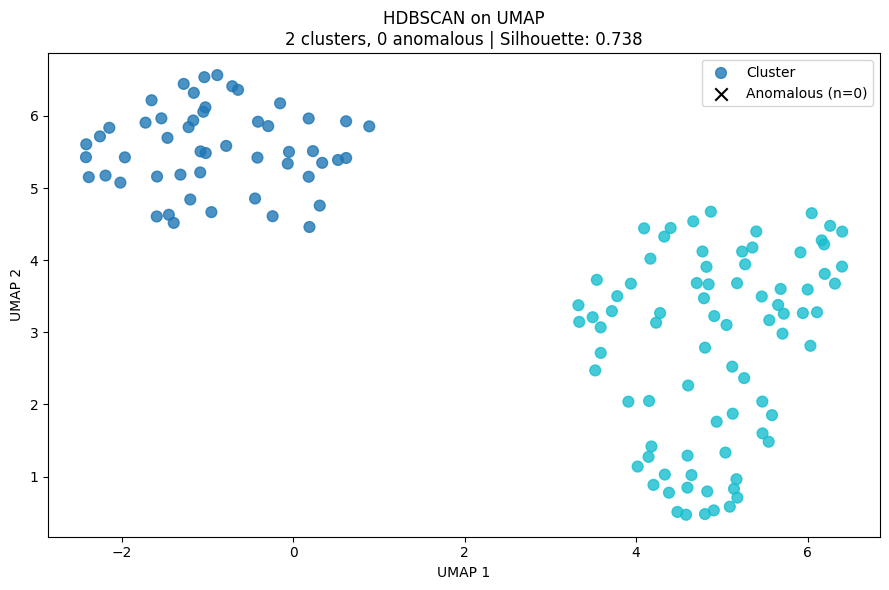

In [79]:
fig, ax = plt.subplots(figsize=(9, 6))

normal = ~safi["is_anomalous"]
ax.scatter(
    safi.loc[normal, "umap_x"], safi.loc[normal, "umap_y"],
    c=safi.loc[normal, "hdbscan_label"], cmap='tab10',
    s=60, alpha=0.8, label='Cluster'
)
ax.scatter(
    safi.loc[safi["is_anomalous"], "umap_x"],
    safi.loc[safi["is_anomalous"], "umap_y"],
    c='black', s=80, marker='x', linewidths=1.5,
    label=f'Anomalous (n={n_anomalous})'
)
ax.set_title(f"HDBSCAN on UMAP\n{n_clusters} clusters, {n_anomalous} anomalous | Silhouette: {sil:.3f}")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend()
plt.tight_layout()
plt.show()

Isolation Forest

In [81]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
safi["is_anomalous"] = iso.fit_predict(X_scaled) == -1

n_anomalous = safi["is_anomalous"].sum()
print(f"Anomalous households: {n_anomalous}")

Anomalous households: 13


 Plot on UMAP space

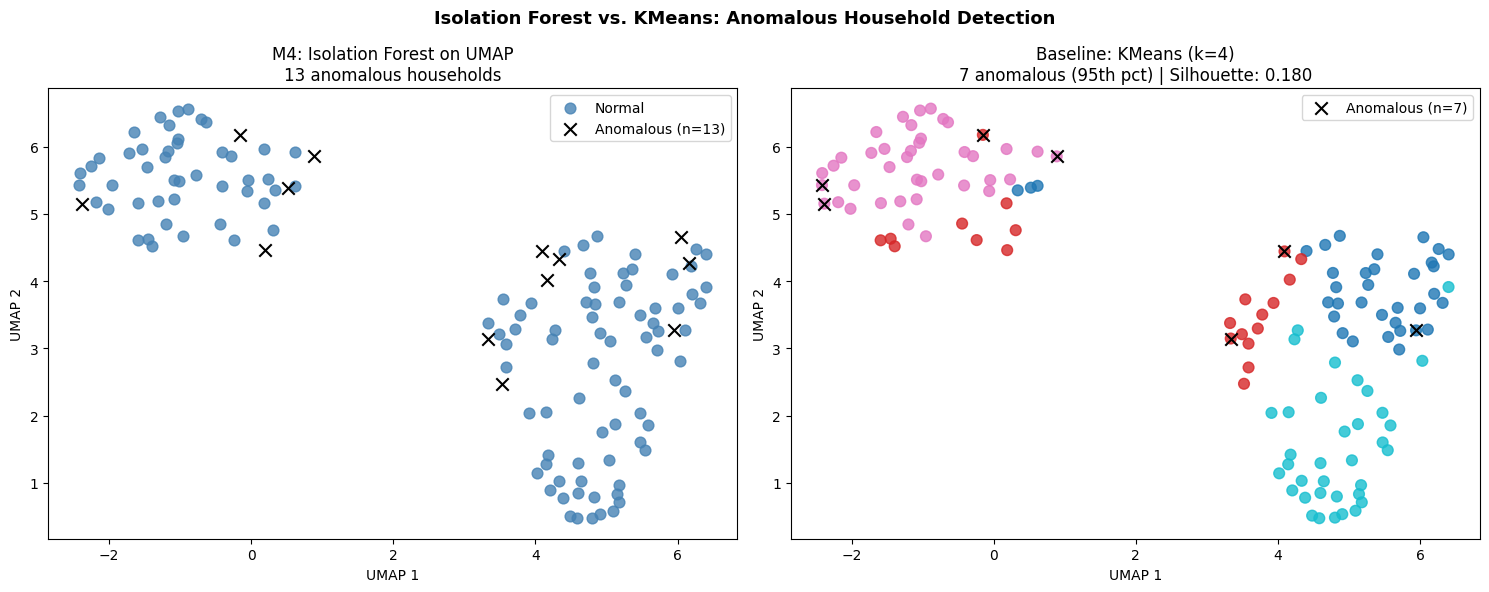

In [82]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)
safi["kmeans_cluster"] = km_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

normal = ~safi["is_anomalous"]
axes[0].scatter(safi.loc[normal, "umap_x"], safi.loc[normal, "umap_y"],
                c='steelblue', s=60, alpha=0.8, label='Normal')
axes[0].scatter(safi.loc[safi["is_anomalous"], "umap_x"],
                safi.loc[safi["is_anomalous"], "umap_y"],
                c='black', s=80, marker='x', linewidths=1.5,
                label=f'Anomalous (n={n_anomalous})')
axes[0].set_title(f"M4: Isolation Forest on UMAP\n{n_anomalous} anomalous households")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
axes[0].legend()

centroids = kmeans.cluster_centers_
distances = np.linalg.norm(X_scaled - centroids[km_labels], axis=1)
km_outlier = distances > np.percentile(distances, 95)
axes[1].scatter(safi["umap_x"], safi["umap_y"],
                c=km_labels, cmap='tab10', s=60, alpha=0.8)
axes[1].scatter(safi.loc[km_outlier, "umap_x"],
                safi.loc[km_outlier, "umap_y"],
                c='black', s=80, marker='x', linewidths=1.5,
                label=f'Anomalous (n={km_outlier.sum()})')
axes[1].set_title(f"Baseline: KMeans (k=4)\n{km_outlier.sum()} anomalous (95th pct) | Silhouette: {km_sil:.3f}")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
axes[1].legend()

plt.suptitle("Isolation Forest vs. KMeans: Anomalous Household Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Method Agreement

In [83]:
overlap = pd.crosstab(safi["is_anomalous"], km_outlier,
                      rownames=["Isolation Forest anomalous"],
                      colnames=["KMeans outlier"])
display(overlap)

both_flag = safi["is_anomalous"] & km_outlier
print(f"\nFlagged by BOTH methods: {both_flag.sum()} — highest-confidence unexpected profiles")

KMeans outlier,False,True
Isolation Forest anomalous,,
False,117,1
True,7,6



Flagged by BOTH methods: 6 — highest-confidence unexpected profiles


Profile Anomalous Households

In [84]:
profile = safi.groupby("is_anomalous")[features].mean().round(2)
profile.index = ["Normal", "Anomalous"]
display(profile)

diff = profile.loc["Anomalous"] - profile.loc["Normal"]
print("\nDifference (Anomalous - Normal):")
print(diff.sort_values(ascending=False).round(2))

,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count
Normal,6.92,2.25,1.61,2.61,2.25,20.81,4.63
Anomalous,9.62,3.38,2.92,2.54,3.00,43.46,5.77



Difference (Anomalous - Normal):
years_liv                 22.65
no_membrs                  2.70
rooms                      1.31
items_owned_count          1.14
liv_count                  1.13
months_lack_food_count     0.75
no_meals                  -0.07
dtype: float64


Feature Profile Bar Chart

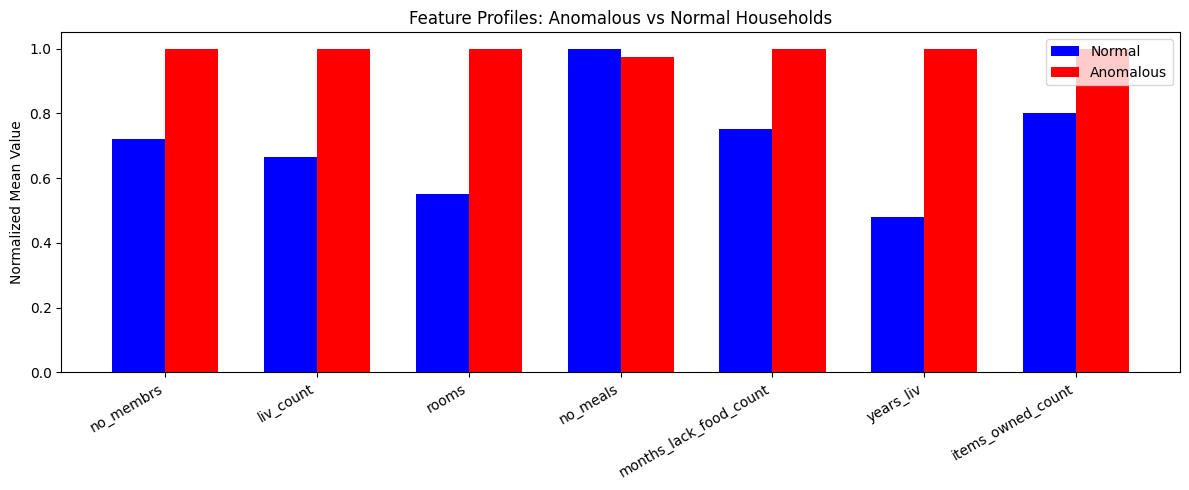

In [90]:
profile_norm = profile.div(profile.max(axis=0), axis=1)
x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, profile_norm.loc["Normal"], width, label='Normal', color='blue')
ax.bar(x + width/2, profile_norm.loc["Anomalous"], width, label='Anomalous', color='red')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha='right')
ax.set_ylabel("Normalized Mean Value")
ax.set_title("Feature Profiles: Anomalous vs Normal Households")
ax.legend()
plt.tight_layout()
plt.show()

 Contextual Breakdown

In [91]:
print("By village:")
display(pd.crosstab(safi["is_anomalous"], safi["village"], normalize="index").round(3))

print("\nBy association membership:")
display(pd.crosstab(safi["is_anomalous"], safi["memb_assoc"], normalize="index").round(3))

print("\nBy conflict exposure:")
display(pd.crosstab(safi["is_anomalous"], safi["affect_conflicts"], normalize="index").round(3))

By village:


village,Chirodzo,God,Ruaca
is_anomalous,,,
False,0.297,0.339,0.364
True,0.308,0.231,0.462



By association membership:


memb_assoc,no,unknown,yes
is_anomalous,,,
False,0.466,0.305,0.229
True,0.308,0.231,0.462



By conflict exposure:


affect_conflicts,frequently,more_once,never,once,unknown
is_anomalous,,,,,
False,0.068,0.220,0.347,0.059,0.305
True,0.077,0.231,0.385,0.077,0.231


Highest Confidence Unexpected Profiles

In [92]:
both_flag = safi["is_anomalous"] & km_outlier
print(f"Flagged by BOTH methods (n={both_flag.sum()}):")
display(safi[both_flag][features + ["village", "memb_assoc", "affect_conflicts"]].reset_index(drop=True))

Flagged by BOTH methods (n=6):


,no_membrs,liv_count,rooms,no_meals,months_lack_food_count,years_liv,items_owned_count,village,memb_assoc,affect_conflicts
0,5,3,2,2,11,30,5,God,yes,once
1,19,5,2,2,0,69,6,Ruaca,yes,more_once
2,2,3,3,2,0,60,0,Chirodzo,unknown,unknown
3,4,1,8,2,3,18,1,Chirodzo,unknown,unknown
4,5,5,2,3,3,25,15,Ruaca,no,never
5,6,5,1,3,3,96,5,Ruaca,no,never
